# Thematic Analysis of Clinical Trial Trends

## Objectives

- Explore is summaries under the same condition share similar themes.

## Inputs

- data/outputs/clinical_trials_clustered.csv

## Outputs

- data/outputs/clinical_trials_clustered.csv (Dataset remians unchanged)

__________

Import necessary libraries to conduct the thematic analysis.

In [3]:
# Import libraries (assistance from ChatGPT)
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.feature_extraction.text import TfidfVectorizer
import pprint
from sklearn.metrics.pairwise import cosine_similarity

Load the dataset into a Pandas DataFrame.

In [5]:
# Load the dataset
df = pd.read_csv('../data/outputs/clinical_trials_clustered.csv')

# Display the first few row of the DataFrame
df.head(1)

,Unnamed: 0,Sponsor,Title,Summary,Start_Year,Start_Month,Phase,Enrollment,Status,Condition,Start_Month_Name,Start_Year_Period,Enrolled_Participants,Condition_cleaned,Condition_cluster,Condition_grouped
0,0,GSK,"An Open-Label, Non-Randomized Pharmacokinetic ...",The main purpose of this study is to compare h...,2006,9,Phase 1,29,Completed,"Purpura, Thrombocytopenic, Idiopathic",September,2006-2010,<50,purpura thrombocytopenic idiopathic,0,Other


Group the summaries by condition.

In [6]:
# Group the summaries by condition (assistance from ChatGPT)
grouped_summaries = df.groupby('Condition_grouped')['Summary'].apply(lambda x: ' '.join(x.dropna())).reset_index()

Clean and vectorize the text using TF-IDF to capture keywords per condition.

In [7]:
# Vectorize the grouped text
vectorizer = TfidfVectorizer(stop_words='english', max_features=1000)
X = vectorizer.fit_transform(grouped_summaries['Summary'])


Extract the top keywords per condition, to help see what each condition is focusing on. 

In [10]:
# Extract the top keywords per condition
feature_names = vectorizer.get_feature_names_out()

top_n = 20  # top 20 keywords
keywords_per_condition = {}

for i, row in enumerate(X.toarray()):
    top_indices = row.argsort()[::-1][:top_n]
    keywords = [feature_names[j] for j in top_indices]
    condition = grouped_summaries['Condition_grouped'].iloc[i]
    keywords_per_condition[condition] = keywords

# View result
import pprint
pprint.pprint(keywords_per_condition)


{"Alzheimer's Disease": ['alzheimer',
                         'study',
                         'ad',
                         'disease',
                         'safety',
                         'patients',
                         'mild',
                         'subjects',
                         'tolerability',
                         'moderate',
                         'placebo',
                         'cognitive',
                         'healthy',
                         'participants',
                         'evaluate',
                         'assess',
                         'purpose',
                         'treatment',
                         'doses',
                         'brain'],
 'Anemia': ['study',
            'epoetin',
            'anemia',
            'alfa',
            'mircera',
            'patients',
            'treatment',
            'dose',
            'hemoglobin',
            'chronic',
            'dialysis',
            'kidney',
  

Generate WordClouds for each goruped conditin based on the TF-IDF scores, displaying each word a size proportional to its importance.

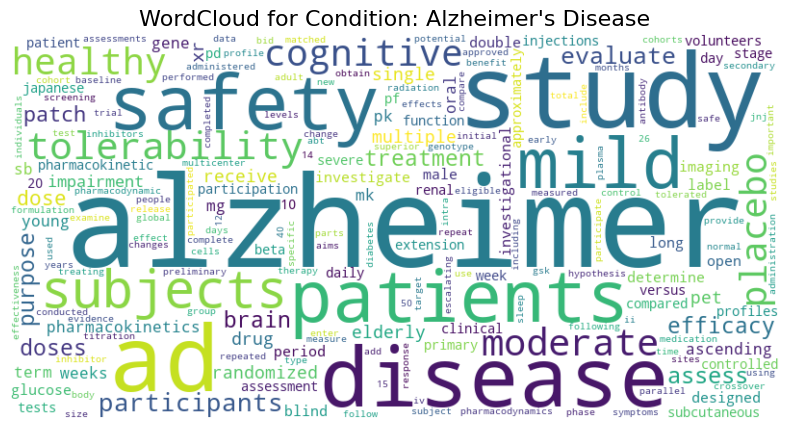

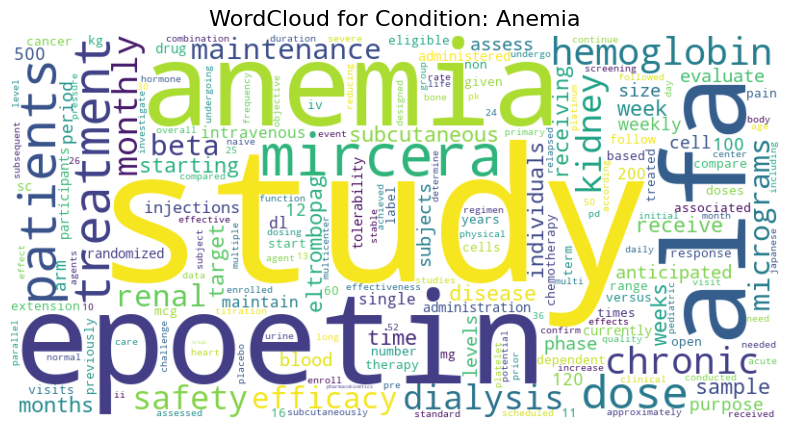

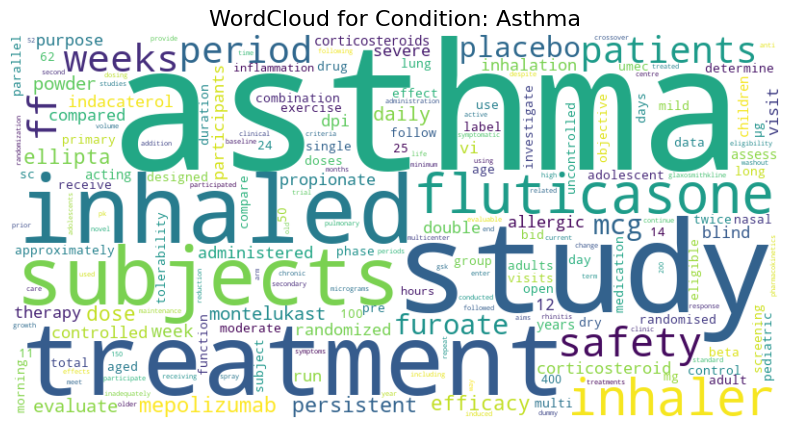

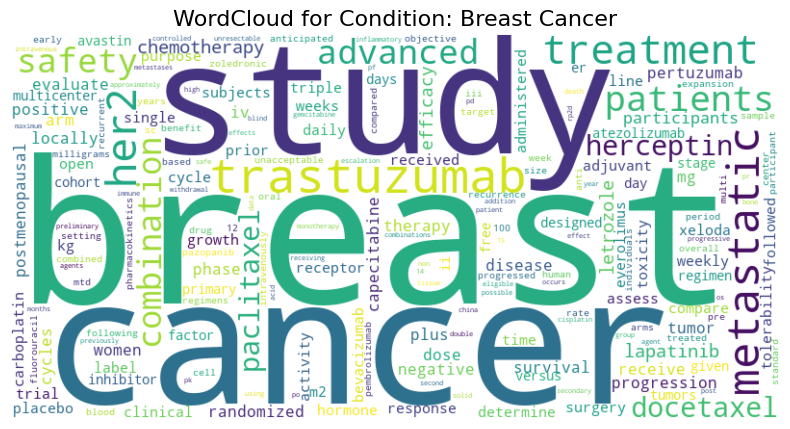

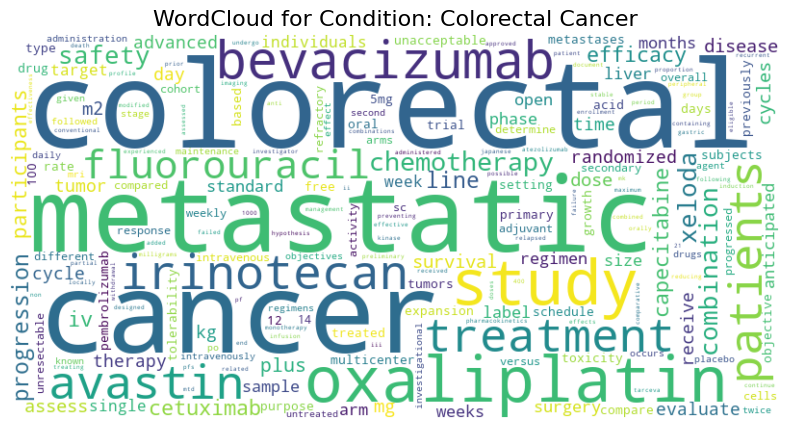

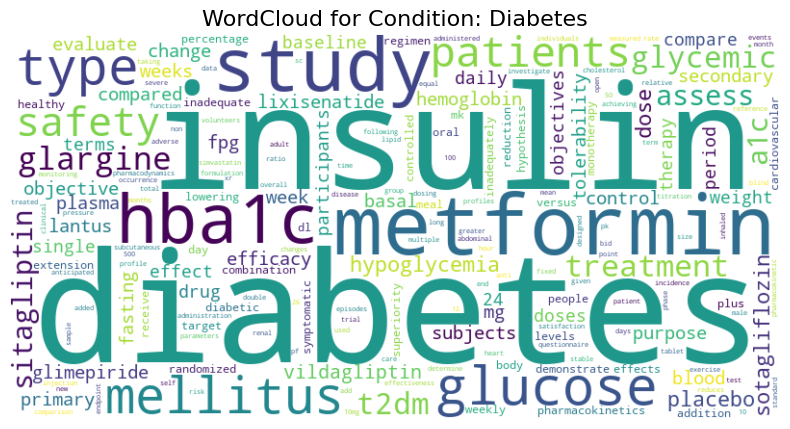

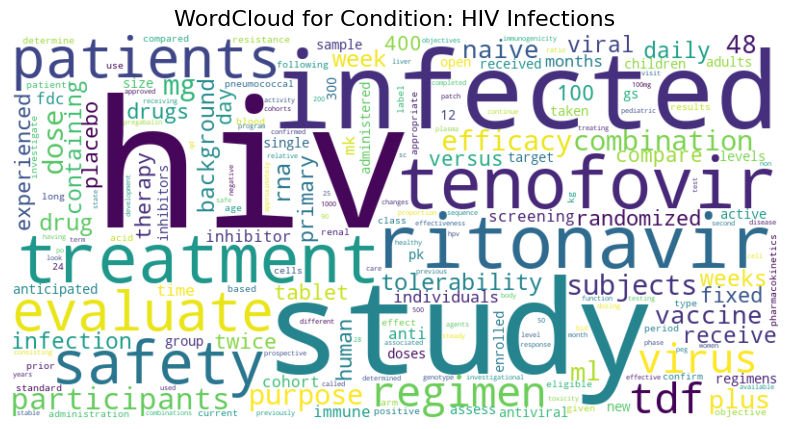

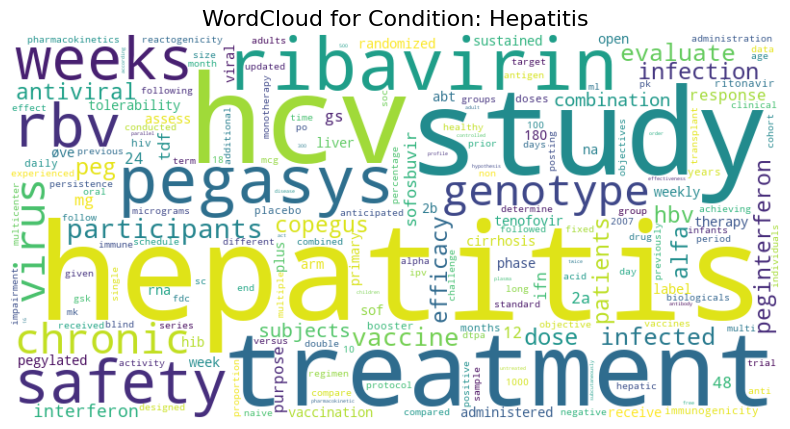

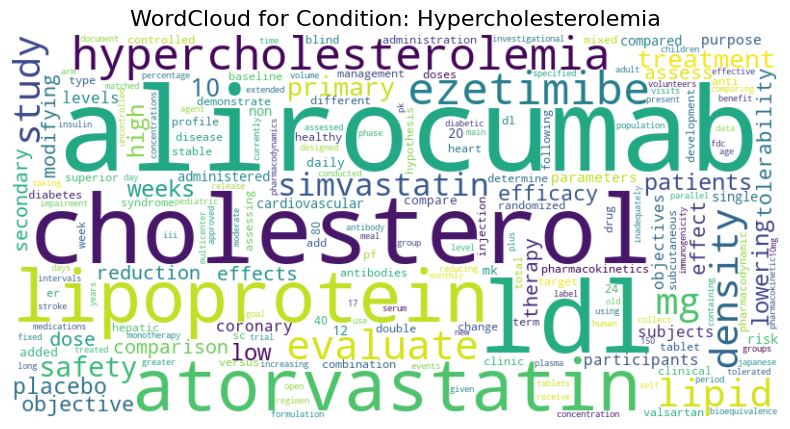

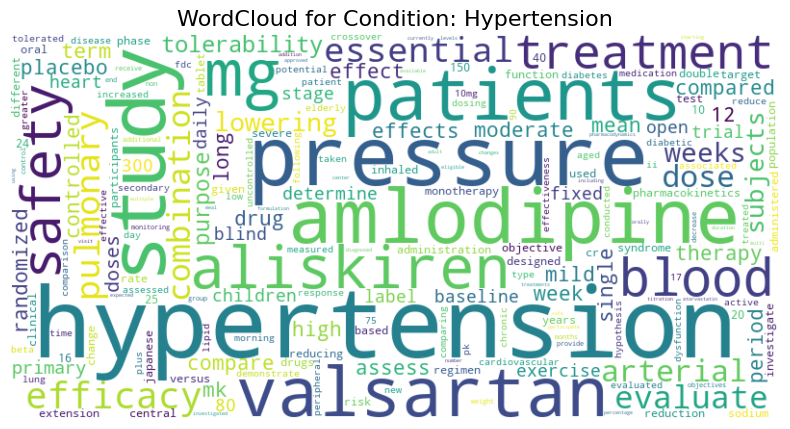

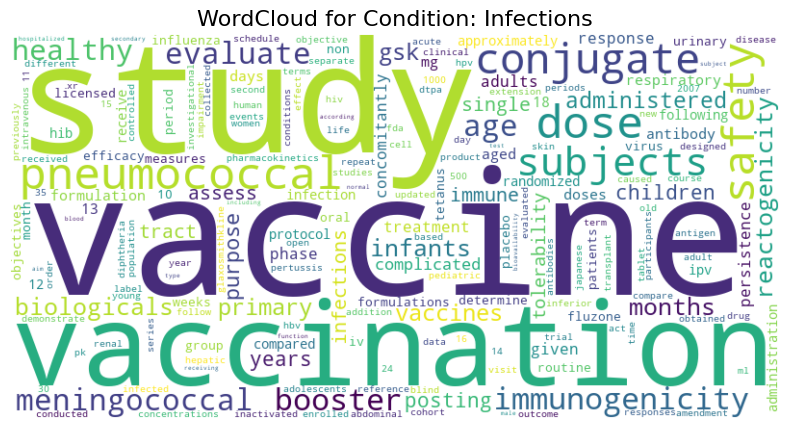

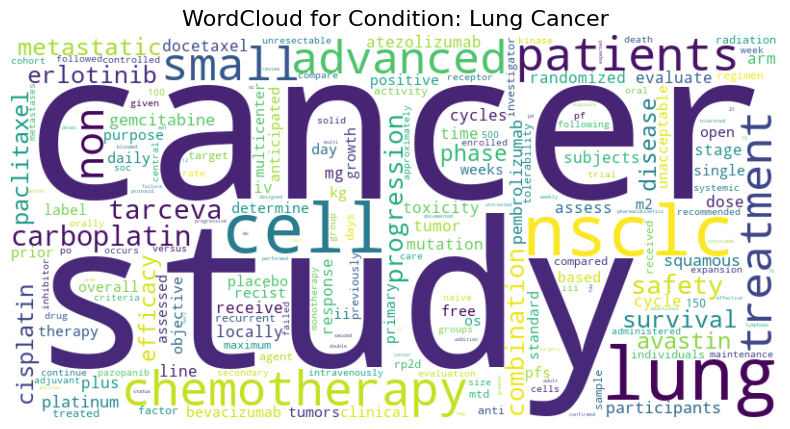

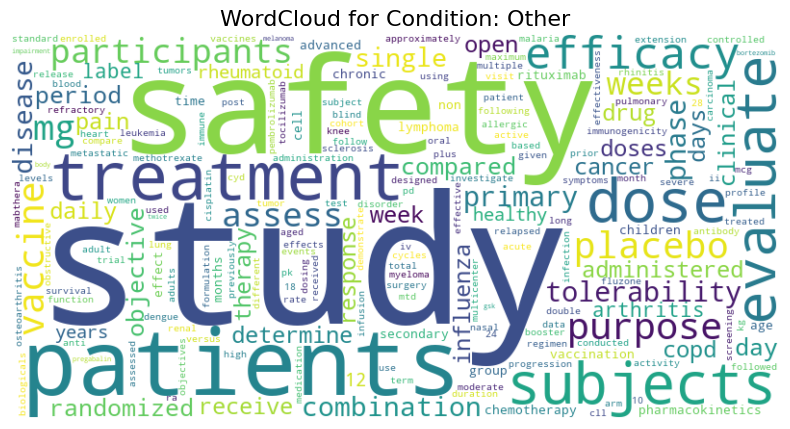

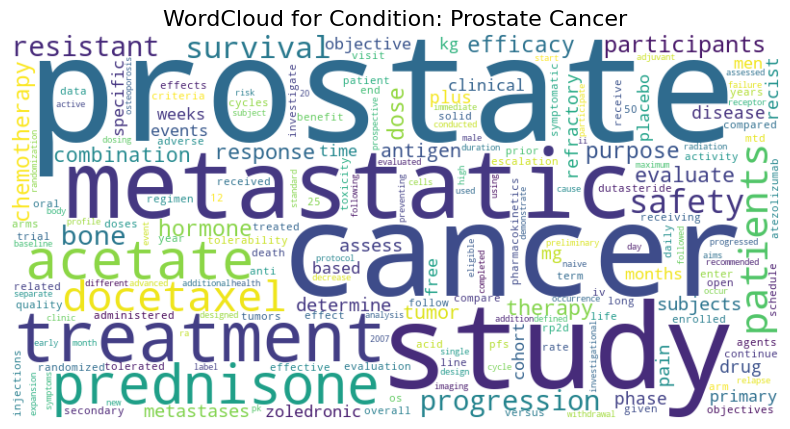

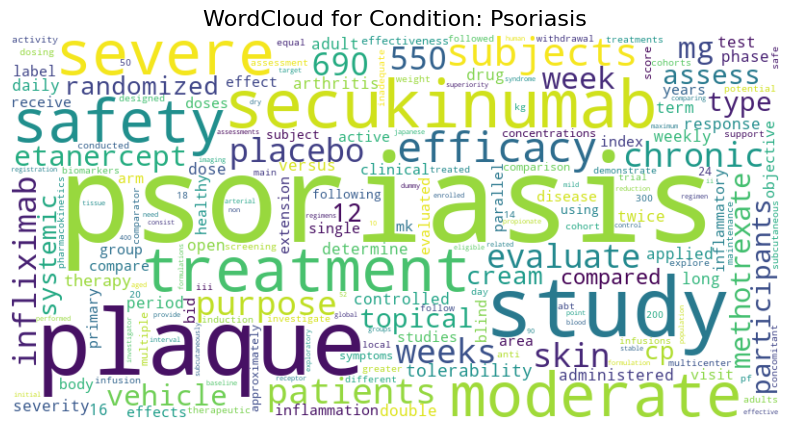

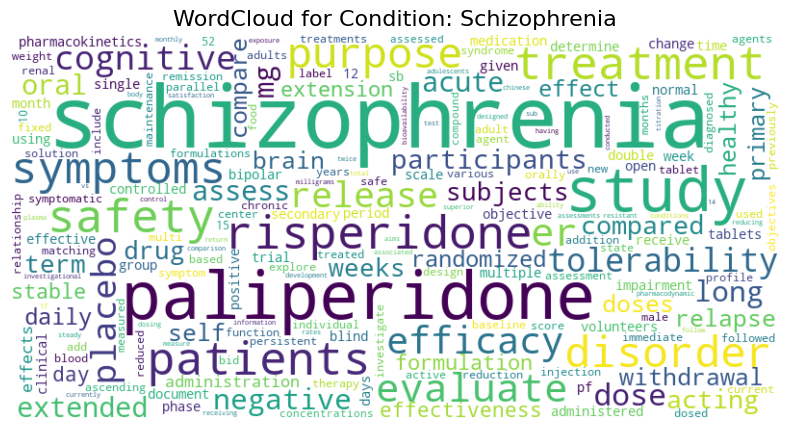

In [11]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

# Loop through each condition and create a wordcloud using actual TF-IDF scores
for i, row in enumerate(X.toarray()):
    condition = grouped_summaries['Condition_grouped'].iloc[i]
    tfidf_scores = {feature_names[j]: row[j] for j in row.nonzero()[0]}  # Only non-zero scores

    wordcloud = WordCloud(width=800, height=400, background_color='white').generate_from_frequencies(tfidf_scores)

    plt.figure(figsize=(10, 5))
    plt.imshow(wordcloud, interpolation='bilinear')
    plt.axis('off')
    plt.title(f"WordCloud for Condition: {condition}", fontsize=16)
    plt.show()
